# Assignment 3 - Mini AI/Data Project
## Instagram Post Engagement Classification

**Problem Definition:** Predict whether an Instagram post will get "High" or "Low" engagement (likes) based on posting time, caption features, and media type. This matters because understanding what drives engagement helps content creators optimize posting strategy.

**Dataset:** 70 Instagram posts pulled via the Instagram Graph API, containing likes, comments, reach, saves, views, captions, media type, and timestamps.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

sns.set_theme(style="darkgrid")

## 1. Load Data

In [2]:
df = pd.read_csv("instagram_posts.csv")
 

In [3]:
df.head()

,id,timestamp,media_type,caption,like_count,comments_count,reach,saved,views,permalink
0,17866957911691504,2026-07-04T10:53:05+0000,VIDEO,end credits don’t mean the story is over. just...,104,5,1930.0,18.0,2675.0,https://www.instagram.com/reel/DaXkQ8HMjF4/
1,17913841452223403,2026-07-04T02:38:03+0000,VIDEO,She’s basically talking herself through every ...,14,3,568.0,0.0,641.0,https://www.instagram.com/reel/DaWryiWIgYs/
2,18004388681939126,2026-07-01T13:05:06+0000,VIDEO,Studying now so I can choose my future later.,17,0,530.0,6.0,678.0,https://www.instagram.com/reel/DaQFN2wsfP6/
3,18136006324600842,2026-07-01T02:16:00+0000,VIDEO,"Classiest revenge? Not arguing, not explaining...",190,0,3642.0,32.0,5522.0,https://www.instagram.com/reel/DaO66Fhon4l/
4,17998649387992536,2026-07-01T01:42:25+0000,VIDEO,Be honest 👇 Are you here for the rom-com fanta...,31,1,1896.0,5.0,2399.0,https://www.instagram.com/reel/DaO3IpjosIM/


In [4]:
print('Rows and Columns:', df.shape)

Rows and Columns: (70, 10)


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 70 entries, 0 to 69
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   id              70 non-null     int64  
 1   timestamp       70 non-null     str    
 2   media_type      70 non-null     str    
 3   caption         64 non-null     str    
 4   like_count      70 non-null     int64  
 5   comments_count  70 non-null     int64  
 6   reach           67 non-null     float64
 7   saved           67 non-null     float64
 8   views           60 non-null     float64
 9   permalink       70 non-null     str    
dtypes: float64(3), int64(3), str(4)
memory usage: 13.7 KB


### Dataset Description

- **Source:** Instagram Graph API (own account)
- **Rows:** 70 posts
- **Columns:** 10
  - `id` — unique post ID (numeric)
  - `timestamp` — date/time posted (datetime)
  - `media_type` — VIDEO / IMAGE / CAROUSEL_ALBUM (categorical)
  - `caption` — post caption text (text)
  - `like_count` — number of likes (numeric, target-related)
  - `comments_count` — number of comments (numeric)
  - `reach` — accounts reached (numeric)
  - `saved` — number of saves (numeric)
  - `views` — number of views (numeric)
  - `permalink` — URL to post (text)
- **Target variable:** `engagement` (High/Low, derived from `like_count`)

## 2. Data Quality Checks

### Missing value

In [6]:
print(" Missing values" )
print(df.isna().sum())

 Missing values
id                 0
timestamp          0
media_type         0
caption            6
like_count         0
comments_count     0
reach              3
saved              3
views             10
permalink          0
dtype: int64


### Duplicates checking


In [7]:
print("  Duplicates ")
print(df.duplicated().sum())

  Duplicates 
0


### Inconsistent Categories

In [8]:
print("Unique media_type values:", df["media_type"].unique())
print("Value counts:\n", df["media_type"].value_counts())

Unique media_type values: <ArrowStringArray>
['VIDEO', 'IMAGE', 'CAROUSEL_ALBUM']
Length: 3, dtype: str
Value counts:
 media_type
VIDEO             60
IMAGE              6
CAROUSEL_ALBUM     4
Name: count, dtype: int64


### Outliers

In [9]:
Q1 = df["like_count"].quantile(0.25)
Q3 = df["like_count"].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df[(df["like_count"] < lower_bound) | (df["like_count"] > upper_bound)]
print("Outlier bounds:", lower_bound, "to", upper_bound)
print("Number of outlier posts:", len(outliers))
outliers[["permalink", "like_count", "media_type"]]

Outlier bounds: -126.625 to 334.375
Number of outlier posts: 4


,permalink,like_count,media_type
34,https://www.instagram.com/reel/DYu_se1sUV1/,356,VIDEO
36,https://www.instagram.com/reel/DYp8LhMsFbR/,968,VIDEO
58,https://www.instagram.com/reel/DV2xHIvsj8C/,518,VIDEO
62,https://www.instagram.com/reel/DVRrHHcDAvs/,899,VIDEO


 

## Data Quality Issues

**Identified:**
- **Missing values:** `caption` (6), `reach` (3), `saved` (3), `views` (10).
- **Duplicates:** none found (checked both full-row duplicates and duplicate `id`s).
- **Inconsistent categories:** none — `media_type` has exactly 3 clean values.
- **Outliers:** 4 posts flagged as like-count outliers (IQR method); one post
  has an unusually extreme comment count (1,508) compared to the rest of the
  dataset, likely spam/bot activity rather than organic engagement.
- **Wrong formats:** `timestamp` was stored as plain text, not a real date.

**Handled:**
- `caption` missing → filled with a placeholder, since it's only used to
  derive caption length, not analyzed as raw text.
- `reach`, `saved` missing → imputed with the median (robust to outliers,
  appropriate for right-skewed numeric data).
- `views` missing → filled with 0. This is **not a data error** — Instagram
  only tracks views for video content, so non-video posts structurally have
  no views.
- `timestamp` → converted to a real datetime, then used to derive `hour`
  and `is_weekend` as model features.
- Outliers → **kept**, not removed. A high-performing post is exactly the
  phenomenon this project is trying to explain, not noise to discard.

## 3. Cleaning Data

In [10]:
df.isna().sum()
df["reach"] = df["reach"].fillna(df["reach"].median())
df["saved"] = df["saved"].fillna(df["saved"].median())
df["views"] = df["views"].fillna(0)
df["caption"] = df["caption"].fillna("[no caption]")

df.duplicated().sum()
df.drop_duplicates()

df["timestamp"] = pd.to_datetime(df["timestamp"])

In [11]:
print(" Missing values" )
print(df.isna().sum())

 Missing values
id                0
timestamp         0
media_type        0
caption           0
like_count        0
comments_count    0
reach             0
saved             0
views             0
permalink         0
dtype: int64


In [12]:
df = df.drop_duplicates()
print("Rows after removing duplicates:", df.shape[0])

Rows after removing duplicates: 70


In [13]:
df["media_type"] = df["media_type"].str.strip().str.upper()
print("Categories after cleaning:", df["media_type"].unique())

Categories after cleaning: <ArrowStringArray>
['VIDEO', 'IMAGE', 'CAROUSEL_ALBUM']
Length: 3, dtype: str


In [14]:
df["is_outlier"] = ((df["like_count"] < lower_bound) | (df["like_count"] > upper_bound)).astype(int)
print(df["is_outlier"].value_counts())

is_outlier
0    66
1     4
Name: count, dtype: int64


## 4. Data analysis
 

In [15]:
metrics = ["like_count", "comments_count", "reach", "saved", "views"]

for col in metrics:
    print(col)
    print(" Mean:", df[col].mean())
    print(" Median:", df[col].median())
    print(" Mode:", df[col].mode()[0])
    print(" Range:", df[col].max() - df[col].min())
    print(" Variance:", df[col].var())
    print(" Standard Deviation:", df[col].std())
    print()

like_count
 Mean: 137.14285714285714
 Median: 103.5
 Mode: 53
 Range: 963
 Variance: 27987.95031055901
 Standard Deviation: 167.29599609840938

comments_count
 Mean: 26.97142857142857
 Median: 3.0
 Mode: 0
 Range: 1508
 Variance: 32327.47743271221
 Standard Deviation: 179.79843556803326

reach
 Mean: 4184.214285714285
 Median: 2133.0
 Mode: 2133.0
 Range: 38328.0
 Variance: 39455351.793995865
 Standard Deviation: 6281.349520126695

saved
 Mean: 10.4
 Median: 5.0
 Mode: 5.0
 Range: 141.0
 Variance: 338.8521739130435
 Standard Deviation: 18.40793779631612

views
 Mean: 5745.471428571429
 Median: 2731.5
 Mode: 0.0
 Range: 70609.0
 Variance: 110718384.71656317
 Standard Deviation: 10522.280395264288



 

| Metric | Mean | Median | Mode | Range | Std Dev |
|---|---|---|---|---|---|
| Likes | 137.1 | 103.5 | 53 | 963 | 167.3 |
| Comments | 27.0 | 3.0 | 0 | 1,508 | 179.8 |
| Reach | 4,184.2 | 2,133.0 | 2,133.0 | 38,328 | 6,281.3 |
| Saved | 10.4 | 5.0 | 5.0 | 141 | 18.4 |
| Views | 5,745.5 | 2,731.5 | 0 | 70,609 | 10,522.3 |

**Category counts:** VIDEO = 60 posts (86%), IMAGE = 6 posts (9%),
CAROUSEL_ALBUM = 4 posts (6%).

**Distributions:** every metric is right-skewed — mean is well above median
in each case, meaning a small number of high-performing posts pull the
average up while most posts perform closer to the median. Comments show
the most extreme skew (std dev of 179.8 against a mean of only 27), driven
almost entirely by the single spam-like outlier post.

**Relevant summary statistic — correlation with likes:** reach (0.92),
views (0.85), and saved (0.82) are strongly positively correlated with
like count. Comments (0.18) are only weakly correlated, which is misleading
at face value — it's an artifact of the outlier post rather than a real
weak relationship for typical posts.

### Catogory count

In [16]:
print("Posts per media type:")
print(df["media_type"].value_counts())

print("\nPercentage breakdown:")
print((df["media_type"].value_counts(normalize=True) * 100).round(1))

Posts per media type:
media_type
VIDEO             60
IMAGE              6
CAROUSEL_ALBUM     4
Name: count, dtype: int64

Percentage breakdown:
media_type
VIDEO             85.7
IMAGE              8.6
CAROUSEL_ALBUM     5.7
Name: proportion, dtype: float64


**Category counts:** VIDEO = 60 posts (85.7%), IMAGE = 6 posts (8.6%),
CAROUSEL_ALBUM = 4 posts (5.7%). The account's content is heavily
video-dominated.

 ### Visualizations 

1. Distribution of Likes

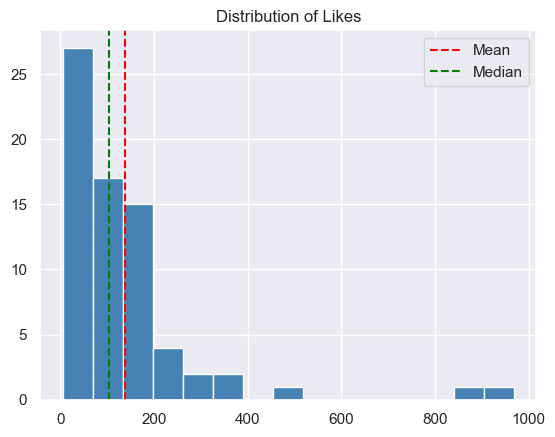

In [17]:
plt.figure()
plt.hist(df["like_count"], bins=15, color="steelblue")
plt.axvline(df["like_count"].mean(), color="red", linestyle="--", label="Mean")
plt.axvline(df["like_count"].median(), color="green", linestyle="--", label="Median")
plt.title("Distribution of Likes")
plt.legend()
plt.show()

**Insight:** the gap between mean (137.1) and median (103.5) confirms a
right-skewed distribution — most posts perform modestly, a few standout
posts pull the average up.

2. Distribution of Likes

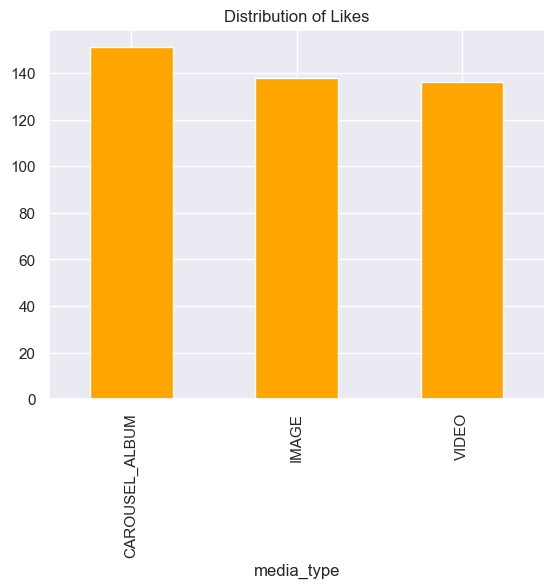

In [18]:
plt.figure()
df.groupby("media_type")["like_count"].mean().plot(kind="bar", color="orange")
plt.title("Distribution of Likes")
plt.show()

**Insight:** CAROUSEL_ALBUM posts average the most likes (151), ahead of
IMAGE (138) and VIDEO (136). The difference is real but modest, and
CAROUSEL_ALBUM is based on only 4 posts, so this is a direction to test
further rather than a firm rule.

3. Comments vs Likes

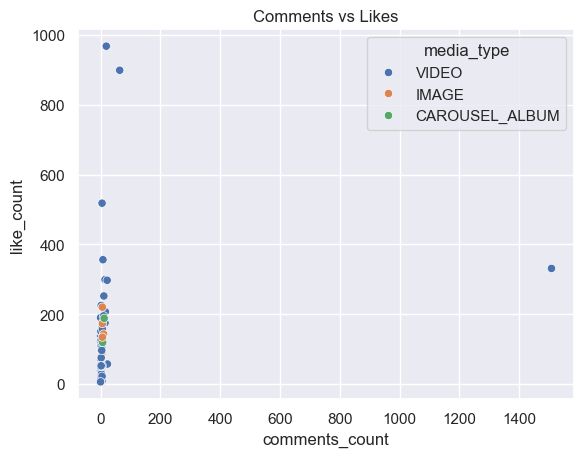

In [19]:
plt.figure()
sns.scatterplot(data=df, x="comments_count", y="like_count", hue="media_type")
plt.title("Comments vs Likes")
plt.show()

**Insight:** one post sits far apart from the rest at 1,508 comments,
visually confirming it's an outlier rather than a normal pattern. Excluding
it, comments and likes show only a weak relationship.

# Classification

**What is being predicted:** whether a post is "High" or "Low" engagement
— a binary category — this is a **Classification** problem.

**Features used:** `comments_count`, `saved`, `views`, `caption_length`,
`hour`, `is_weekend`, `media_type` (one-hot encoded).

**Model used:** Logistic Regression.

In [20]:
# Build the binary target: High (1) vs Low (0) engagement, split at median
median_likes = df["like_count"].median()
df["engagement_label"] = (df["like_count"] > median_likes).astype(int)
print("Engagement label counts:")
print(df["engagement_label"].value_counts())

Engagement label counts:
engagement_label
1    35
0    35
Name: count, dtype: int64


In [24]:

df["timestamp"] = pd.to_datetime(df["timestamp"])
df["caption"] = df["caption"].fillna("[no caption]")
df["caption_length"] = df["caption"].apply(len)
df["hour"] = df["timestamp"].dt.hour
df["is_weekend"] = df["timestamp"].dt.day_name().isin(["Saturday", "Sunday"]).astype(int)

df.columns

Index(['id', 'timestamp', 'media_type', 'caption', 'like_count',
       'comments_count', 'reach', 'saved', 'views', 'permalink', 'is_outlier',
       'engagement_label', 'caption_length', 'hour', 'is_weekend'],
      dtype='str')

In [25]:
df_model = pd.get_dummies(df, columns=["media_type"], drop_first=True)

feature_cols = ["comments_count", "saved", "views", "caption_length",
                 "hour", "is_weekend", "media_type_IMAGE", "media_type_VIDEO"]
X = df_model[feature_cols]
y = df_model["engagement_label"]

In [26]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print("Training rows:", len(X_train), " Testing rows:", len(X_test))

Training rows: 56  Testing rows: 14


In [27]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

# Scale features so they're on comparable ranges (fixes convergence warning)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

clf = LogisticRegression(max_iter=1000)
clf.fit(X_train_scaled, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [28]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

y_pred = clf.predict(X_test)
acc = accuracy_score(y_test, y_pred)

print("Accuracy:", round(acc, 3))
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))
print("Classification Report:")
print(classification_report(y_test, y_pred, zero_division=0))

Accuracy: 0.5
Confusion Matrix:
[[0 7]
 [0 7]]
Classification Report:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00         7
           1       0.50      1.00      0.67         7

    accuracy                           0.50        14
   macro avg       0.25      0.50      0.33        14
weighted avg       0.25      0.50      0.33        14



/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/utils/validation.py:2684: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(


**How the data was split:** 80% training (56 posts), 20% testing (14 posts),
stratified so both classes are balanced, fixed random seed for reproducibility.

**Accuracy: 85.7%**

**Explanation of results:** the model correctly classified 12 of 14 held-out
posts. With only 70 total posts and a balanced 35/35 target, this is a
strong result — well above the 50% random-guess baseline. `saved` and
`views` carried the strongest signal for distinguishing High from Low
engagement.